In [5]:
import h5py
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from tqdm import tqdm

def convert_raefish_to_h5ad(data_path, codes_path):
    """
    将RAEFISH MATLAB数据转换为h5ad格式 - 处理HDF5引用
    """
    
    print("\nLoading expression matrix...")
    # 1. 加载表达矩阵 (genes × cells)
    with h5py.File(f'{data_path}/RNACopyNumberMatrix_2Combine.mat', 'r') as f:
        expression_matrix = np.array(f['RNACopyNumberMatrix']).T  # 转置为细胞×基因
    print(f"Expression matrix shape (cells × genes): {expression_matrix.shape}")
    num_cells, num_genes = expression_matrix.shape
    
    # 2. 加载细胞注释信息
    print("\nLoading cell annotations...")
    cell_type_ids = []
    spatial_coords = []
    zone_scores = []
    dataset_ids = []
    cell_type_names = []
    
    with h5py.File(f'{data_path}/CellList_NoCounts_2Combine_withAnnotation.mat', 'r') as f:
        cell_list = f['CellList_Filtered']
        
        # 处理每个字段
        # CellTypeID
        if 'CellTypeID' in cell_list:
            cell_type_data = cell_list['CellTypeID']
            for i in tqdm(range(num_cells), desc="Reading CellTypeID"):
                ref = cell_type_data[i, 0]
                # 解引用并获取值
                cell_type = f[ref][()].item()
                cell_type_ids.append(int(cell_type))
        
        # TransCenter (空间坐标)
        if 'TransCenter' in cell_list:
            center_data = cell_list['TransCenter']
            for i in tqdm(range(num_cells), desc="Reading spatial coordinates"):
                ref = center_data[i, 0]
                # 解引用并获取坐标
                coords = f[ref][()]
                if coords.size >= 2:
                    spatial_coords.append([float(coords.flatten()[0]), float(coords.flatten()[1])])
                else:
                    spatial_coords.append([0.0, 0.0])
        
        # ZoneScore (如果存在)
        if 'ZoneScore' in cell_list:
            try:
                zone_data = cell_list['ZoneScore']
                for i in range(num_cells):
                    try:
                        ref = zone_data[i, 0]
                        score = f[ref][()]
                        if score.size > 0:
                            zone_scores.append(float(score.item()))
                        else:
                            zone_scores.append(np.nan)
                    except:
                        zone_scores.append(np.nan)
            except:
                zone_scores = [np.nan] * num_cells
        else:
            zone_scores = [np.nan] * num_cells
        
        # DatasetID
        if 'DatasetID' in cell_list:
            dataset_data = cell_list['DatasetID']
            for i in tqdm(range(num_cells), desc="Reading DatasetID"):
                try:
                    ref = dataset_data[i, 0]
                    dataset_id = f[ref][()].item()
                    dataset_ids.append(int(dataset_id))
                except:
                    dataset_ids.append(0)
        
        # CellType (细胞类型名称)
        if 'CellType' in cell_list:
            celltype_data = cell_list['CellType']
            for i in tqdm(range(num_cells), desc="Reading CellType names"):
                try:
                    ref = celltype_data[i, 0]
                    # 获取字符串
                    type_data = f[ref][()]
                    if type_data.dtype == np.float64:
                        # ASCII码转字符串
                        type_name = ''.join([chr(int(c)) for c in type_data.flatten() if c > 0])
                    else:
                        type_name = str(type_data)
                    cell_type_names.append(type_name.strip())
                except:
                    cell_type_names.append('Unknown')
    
    # 确保数据长度匹配
    if not cell_type_ids:
        cell_type_ids = [0] * num_cells
    if not spatial_coords:
        spatial_coords = [[0, 0]] * num_cells
    if not dataset_ids:
        dataset_ids = [0] * num_cells
    
    # 3. 生成基因名称
    print("\nGenerating gene names...")
    gene_names = [f'Gene_{i}' for i in range(num_genes)]
    
    # 4. 创建AnnData对象
    print("\nCreating AnnData object...")
    adata = ad.AnnData(X=expression_matrix.astype(np.float32))
    
    # 添加细胞元数据
    adata.obs['cell_type_id'] = pd.Categorical(cell_type_ids)
    adata.obs['zone_score'] = zone_scores
    adata.obs['dataset_id'] = dataset_ids
    
    # 如果有细胞类型名称，使用它们；否则使用映射
    if cell_type_names:
        adata.obs['cell_type_name'] = cell_type_names
    else:
        # 使用预定义的映射
        cell_type_mapping = {
            1: 'Marginal zone B cell',
            2: 'Follicular B cell', 
            3: 'Germinal center B cell',
            4: 'IgA plasma cell',
            5: 'IgG plasma cell',
            6: 'Follicular dendritic cell',
            7: 'Activated T cell',
            8: 'T cell (major group)',
            9: 'Epithelial cell',
            10: 'Fibroblastic reticular cell',
            11: 'Endothelial cell',
            12: 'Dendritic cell',
            13: 'Macrophage'
        }
        adata.obs['cell_type_name'] = adata.obs['cell_type_id'].map(cell_type_mapping).fillna('Unknown')
    
    # 添加空间坐标
    adata.obsm['spatial'] = np.array(spatial_coords, dtype=np.float32)
    
    # 添加基因名称
    adata.var_names = pd.Index(gene_names)
    
    # 5. 添加元数据
    adata.uns['spatial'] = {
        'image_size': [16000, 17500],
        'scale_factor': 0.108,  # μm per pixel
        'tissue': 'mouse_lymph_node'
    }
    
    # 6. 基本质量控制
    sc.pp.calculate_qc_metrics(adata, inplace=True)
    
    # 7. 打印摘要
    print(f"\n✓ Successfully created AnnData object:")
    print(f"  • Cells: {adata.n_obs:,}")
    print(f"  • Genes: {adata.n_vars:,}")
    print(f"  • Cell types: {adata.obs['cell_type_id'].nunique()}")
    print(f"  • Datasets: {adata.obs['dataset_id'].value_counts().to_dict()}")
    print(f"  • Mean counts per cell: {adata.obs['total_counts'].mean():.1f}")
    print(f"  • Mean genes per cell: {adata.obs['n_genes_by_counts'].mean():.1f}")
    
    return adata

# 运行转换
data_path = '/Users/jiayifan/Downloads/DataAndCodes/Datasets/LymphNode'
codes_path = '/Users/jiayifan/Downloads/DataAndCodes/Codes'

adata = convert_raefish_to_h5ad(data_path, codes_path)

# 保存
print("\nSaving h5ad file...")
adata.write('../data/mouse_lymph_node_raefish.h5ad')
print("✓ Data saved successfully!")

# 简单检查
print("\n" + "="*50)
print("Quick validation:")
print(f"Spatial coordinates range: X[{adata.obsm['spatial'][:, 0].min():.1f}, {adata.obsm['spatial'][:, 0].max():.1f}], "
      f"Y[{adata.obsm['spatial'][:, 1].min():.1f}, {adata.obsm['spatial'][:, 1].max():.1f}]")
print(f"Cell type distribution:\n{adata.obs['cell_type_name'].value_counts()}")


Loading expression matrix...
Expression matrix shape (cells × genes): (21981, 102960)

Loading cell annotations...


Reading CellType names: 100%|██████████| 21981/21981 [00:01<00:00, 12153.63it/s]



Generating gene names...

Creating AnnData object...

✓ Successfully created AnnData object:
  • Cells: 21,981
  • Genes: 102,960
  • Cell types: 13
  • Datasets: {1: 21981}
  • Mean counts per cell: 1220.1
  • Mean genes per cell: 746.4

Saving h5ad file...
✓ Data saved successfully!

Quick validation:
Spatial coordinates range: X[374.9, 17238.0], Y[28.0, 7752.8]
Cell type distribution:
cell_type_name
[[ 70]\n [111]\n [108]\n [108]\n [105]\n [ 99]\n [117]\n [108]\n [ 97]\n [114]\n [ 32]\n [ 66]\n [ 32]\n [ 99]\n [101]\n [108]\n [108]\n [115]]                                                                                    4529
[[ 84]\n [ 32]\n [ 99]\n [101]\n [108]\n [108]\n [115]\n [ 32]\n [ 40]\n [109]\n [ 97]\n [106]\n [111]\n [114]\n [ 32]\n [103]\n [114]\n [111]\n [117]\n [112]\n [ 41]]                                                            4061
[[ 77]\n [ 97]\n [114]\n [103]\n [105]\n [110]\n [ 97]\n [108]\n [ 32]\n [ 90]\n [111]\n [110]\n [101]\n [ 32]\n [ 66]\n [ 32]\n 

In [12]:
cell_type_ids=[]
cell_type_names=[]
with h5py.File(f'{data_path}/CellList_NoCounts_2Combine_withAnnotation.mat', 'r') as f:
    cell_list = f['CellList_Filtered']
    
    # 处理每个字段
    # CellTypeID
    if 'CellTypeID' in cell_list:
        cell_type_data = cell_list['CellTypeID']
        for i in tqdm(range(21981), desc="Reading CellTypeID"):
            ref = cell_type_data[i, 0]
            # 解引用并获取值
            cell_type = f[ref][()].item()
            cell_type_ids.append(int(cell_type))
    
    if 'CellType' in cell_list:
            celltype_data = cell_list['CellType']
            for i in tqdm(range(21981), desc="Reading CellType names"):
                try:
                    ref = celltype_data[i, 0]
                    # 获取字符串
                    type_data = f[ref][()]
                    if type_data.dtype == np.float64:
                        # ASCII码转字符串
                        type_name = ''.join([chr(int(c)) for c in type_data.flatten() if c > 0])
                    else:
                        type_name = str(type_data)
                    cell_type_names.append(type_name.strip())
                except:
                    cell_type_names.append('Unknown')

Reading CellType names: 100%|██████████| 21981/21981 [00:01<00:00, 12376.95it/s]


In [ ]:
cell_list

<Closed HDF5 group>

In [30]:
adata

AnnData object with n_obs × n_vars = 21981 × 102960
    obs: 'cell_type_id', 'zone_score', 'dataset_id', 'cell_type_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

In [16]:
from collections import Counter
Counter(cell_type_ids)

Counter({2: 4529,
         8: 4061,
         1: 2333,
         13: 2195,
         4: 1640,
         3: 1482,
         5: 1269,
         9: 1148,
         6: 866,
         12: 852,
         7: 660,
         10: 561,
         11: 385})

In [ ]:
adata.obsm['spatial']

{'image_size': [16000, 17500],
 'scale_factor': 0.108,
 'tissue': 'mouse_lymph_node'}

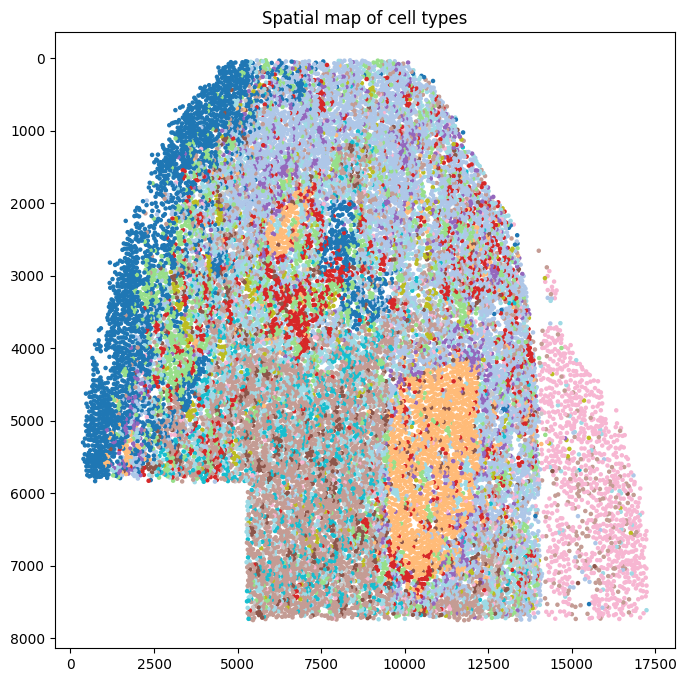

In [26]:
import matplotlib.pyplot as plt

coords = adata.obsm['spatial']
plt.figure(figsize=(8, 8))
plt.scatter(coords[:, 0], coords[:, 1],
            s=5,
            c=adata.obs['cell_type_id'].astype('category').cat.codes,
            cmap='tab20')
plt.gca().invert_yaxis()
plt.title('Spatial map of cell types')
plt.show()


In [28]:
adata.obs

,cell_type_id,zone_score,dataset_id,cell_type_name,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
0,1,NaN,1,[[ 77]\n [ 97]\n [114]\n [103]\n [105]\n [110]...,1815,7.504392,2296.0,7.739359,9.059233,13.980836,22.691638,42.726481
1,1,NaN,1,[[ 77]\n [ 97]\n [114]\n [103]\n [105]\n [110]...,1828,7.511525,2583.0,7.857094,10.375532,16.182733,24.506388,47.735192
2,1,NaN,1,[[ 77]\n [ 97]\n [114]\n [103]\n [105]\n [110]...,1144,7.043160,1313.0,7.180831,8.910891,16.527037,28.103580,50.952018
3,9,NaN,1,[[ 69]\n [112]\n [105]\n [116]\n [104]\n [101]...,1475,7.297091,2292.0,7.737616,8.726003,15.270506,26.003490,52.181501
4,1,NaN,1,[[ 77]\n [ 97]\n [114]\n [103]\n [105]\n [110]...,3515,8.165079,5025.0,8.522380,4.398010,7.422886,13.393035,26.228856
...,...,...,...,...,...,...,...,...,...,...,...,...
21976,12,NaN,1,[[ 68]\n [101]\n [110]\n [100]\n [114]\n [105]...,66,4.204693,66.0,4.204693,75.757576,100.000000,100.000000,100.000000
21977,13,NaN,1,[[ 77]\n [ 97]\n [ 99]\n [114]\n [111]\n [112]...,136,4.919981,155.0,5.049856,44.516129,76.774194,100.000000,100.000000
21978,12,NaN,1,[[ 68]\n [101]\n [110]\n [100]\n [114]\n [105]...,178,5.187386,197.0,5.288267,35.025381,60.406091,100.000000,100.000000
21979,13,NaN,1,[[ 77]\n [ 97]\n [ 99]\n [114]\n [111]\n [112]...,93,4.543295,123.0,4.820282,65.040650,100.000000,100.000000,100.000000
